# Classificação de Tumores: Benignos ou Malignos


Tumores são caracterizados pelo crescimento anormal e descontrolado de células humanas. Eles podem ser classificados como **benignos**, quando não oferecem risco à vida, ou **malignos**, quando invadem tecidos adjacentes e podem se espalhar para outras partes do corpo — processo conhecido como **metástase**.

Segundo o DATASUS:

> "As neoplasias constituem a terceira causa de morte no Brasil, representando, em 1998, 14% dos óbitos informados. As estimativas para o ano 2001 indicam a ocorrência de aproximadamente 305 mil casos e 117 mil óbitos por tumores malignos."

Um dos principais desafios no combate ao câncer é o **diagnóstico tardio**. Muitos sintomas são imperceptíveis nas fases iniciais da doença, e os exames laboratoriais nem sempre são rápidos ou conclusivos. Dessa forma, modelos de aprendizado de máquina podem auxiliar no **diagnóstico precoce**, classificando os tumores com base em características extraídas de exames.

Neste projeto, lidamos com um problema de **classificação binária**, onde o objetivo é prever se um tumor é benigno (`0`) ou maligno (`1`) a partir de diversas medidas estatísticas obtidas via exames.

---

### Variáveis do Conjunto de Dados

O conjunto de dados contém as seguintes informações para cada paciente:

1. **ID** — Número de identificação do paciente  
2. **Diagnóstico** — Variável-alvo (1 = Maligno, 0 = Benigno)  
3. **Raio** — Média das distâncias do centro aos pontos do perímetro  
4. **Textura** — Desvio padrão dos valores da escala de cinza  
5. **Perímetro**  
6. **Área**  
7. **Lisura** — Variação local nos comprimentos do raio  
8. **Compacidade** — Fórmula: (perímetro² / área) − 1,0  
9. **Concavidade** — Gravidade das partes côncavas do contorno  
10. **Pontos Côncavos** — Quantidade de regiões côncavas no contorno  
11. **Simetria**  
12. **Dimensão Fractal**

Cada uma dessas variáveis foi calculada em três contextos diferentes:

- **Mean** — Média dos valores  
- **SE (Standard Error)** — Erro padrão  
- **Worst** — Pior ou maior valor observado

Esses subconjuntos serão analisados separadamente para extrair o máximo de informação estatística possível na etapa de modelagem.

## Importação das Bibliotecas


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (balanced_accuracy_score,
                             confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve,roc_auc_score, auc, RocCurveDisplay
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)




Carregando o DataFrame

In [2]:
df_cancer = pd.read_csv("cancer_classification.csv")
df_cancer.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Estrutura do DataFrame

A base de dados utilizada contém **569 amostras** e **31 variáveis**, todas completas, ou seja, **sem valores ausentes**.

### ✅ Informações gerais:
- **Formato:** `pandas.DataFrame`
- **Número de entradas:** 569
- **Número de colunas:** 31
- **Tipos de dados:**
  - `float64`: 30 colunas (variáveis numéricas contínuas)
  - `int64`: 1 coluna (variável alvo)

### 📌 Principais grupos de variáveis

As 30 variáveis preditoras representam medidas estatísticas extraídas de exames clínicos, organizadas em três subconjuntos:

- **Mean (Média):** características médias da célula (ex: `mean radius`, `mean texture`, ...).
- **Error (Erro padrão):** variações estatísticas das medidas (`radius error`, `texture error`, ...).
- **Worst (Pior caso):** valores mais extremos observados (ex: `worst area`, `worst concavity`, ...).

A variável **`benign_0__mal_1`** é a **variável-alvo**, onde:
- `0` representa um tumor **benigno**.
- `1` representa um tumor **maligno**.

### 🧪 Considerações
Essa estrutura rica e bem segmentada permite aplicar diversas técnicas de pré-processamento e seleção de variáveis, além de facilitar a criação de modelos robustos de classificação.

Em seguida, vamos investigar estatísticas descritivas e correlações entre as variáveis para entender melhor os padrões nos dados.


In [3]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## Estatísticas Descritivas

Para entender melhor a distribuição e a variação das variáveis numéricas, utilizamos o método `describe()`. Ele fornece estatísticas resumidas, como:

- **count**: número de amostras (todas com 569, ou seja, sem valores ausentes),
- **mean**: média dos valores,
- **std**: desvio padrão (dispersão),
- **min** e **max**: valores extremos observados,
- **25%, 50%, 75%**: quartis (ajudam a visualizar a distribuição dos dados).

### 📊 O que podemos observar:

- As variáveis que representam **área**, como `mean area` e `worst area`, possuem **valores bem mais altos em média e em amplitude** do que outras variáveis, indicando possível necessidade de **normalização ou padronização**.
- Algumas variáveis como `mean smoothness` e `fractal dimension error` possuem **valores muito pequenos**, o que pode impactar o modelo caso os dados não sejam padronizados.
- A **variabilidade (std)** entre variáveis é bastante diferente, reforçando a importância de pré-processamento estatístico adequado.



In [4]:
df_cancer.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Verificação de Valores Ausentes

Antes de avançar para análises mais profundas e a modelagem, é fundamental verificar se o conjunto de dados possui valores ausentes, pois isso pode impactar diretamente os algoritmos de machine learning.

A inspeção foi realizada com o método `isnull().sum()`, que retorna a quantidade de valores nulos por coluna.

### ✅ Resultado:
Não foram encontrados valores ausentes em nenhuma das 31 colunas do dataset. Isso garante uma base limpa e consistente para a próxima etapa do processo, sem a necessidade de tratamentos como imputação ou remoção de linhas.



In [5]:
df_cancer.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


## Análise de Correlação com a Variável-Alvo

Para entender como cada feature se relaciona com o diagnóstico final (variável `benign_0__mal_1`), foi realizada uma análise de **correlação de Pearson**.

Esse tipo de correlação mede o grau de associação linear entre duas variáveis numéricas, retornando valores no intervalo de **-1 a 1**:

- `+1`: correlação perfeitamente positiva (quando uma variável aumenta, a outra também)
- `0`: ausência de correlação linear
- `-1`: correlação perfeitamente negativa (quando uma variável aumenta, a outra tende a diminuir)

### 📉 Observações:

- A maioria das features apresenta **correlação negativa** com a variável-alvo. Isso significa que, quanto maiores os valores dessas features, **menor a chance de o tumor ser benigno** — ou seja, maior a probabilidade de ser maligno (`1`).
- A feature **`mean concave points`** se destaca por ter uma **correlação negativa forte**, sendo uma das variáveis mais relevantes para a classificação.

### 🔍 Interpretação prática:

Esse tipo de análise é útil para:
- Identificar variáveis **potencialmente mais importantes** na classificação,
- Avaliar **redundância entre atributos** (se for aplicada com um mapa de correlação geral),
- Auxiliar na **seleção de features** ou redução de dimensionalidade futura.

Na próxima etapa, visualizaremos essa correlação por meio de um **heatmap** para facilitar a interpretação visual dessas relações.


In [6]:
df_cancer.corr()['benign_0__mal_1'].sort_values(ascending=True)

,benign_0__mal_1
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


## Distribuição das Classes da Variável-Alvo

Antes de treinar modelos de classificação, é importante analisar o balanceamento das classes da variável-alvo `benign_0__mal_1`, onde:

- `0` representa tumores **benignos**;
- `1` representa tumores **malignos**.

### 📊 Visualização:

O gráfico de barras mostra a frequência de cada classe no dataset.

### 🔎 Observações:

- A base de dados apresenta um **leve desbalanceamento**, com **mais casos de tumores malignos (1)** do que benignos (0).
- Esse desbalanceamento pode influenciar o desempenho dos modelos, fazendo com que eles tendam a favorecer a classe majoritária.
- Estratégias como **ponderação de classes**, **oversampling (ex: SMOTE)** ou **undersampling** podem ser consideradas posteriormente, caso o desempenho nos testes mostre viés.

Manter esse tipo de análise inicial ajuda a tomar decisões mais conscientes durante a modelagem e avaliação dos resultados.


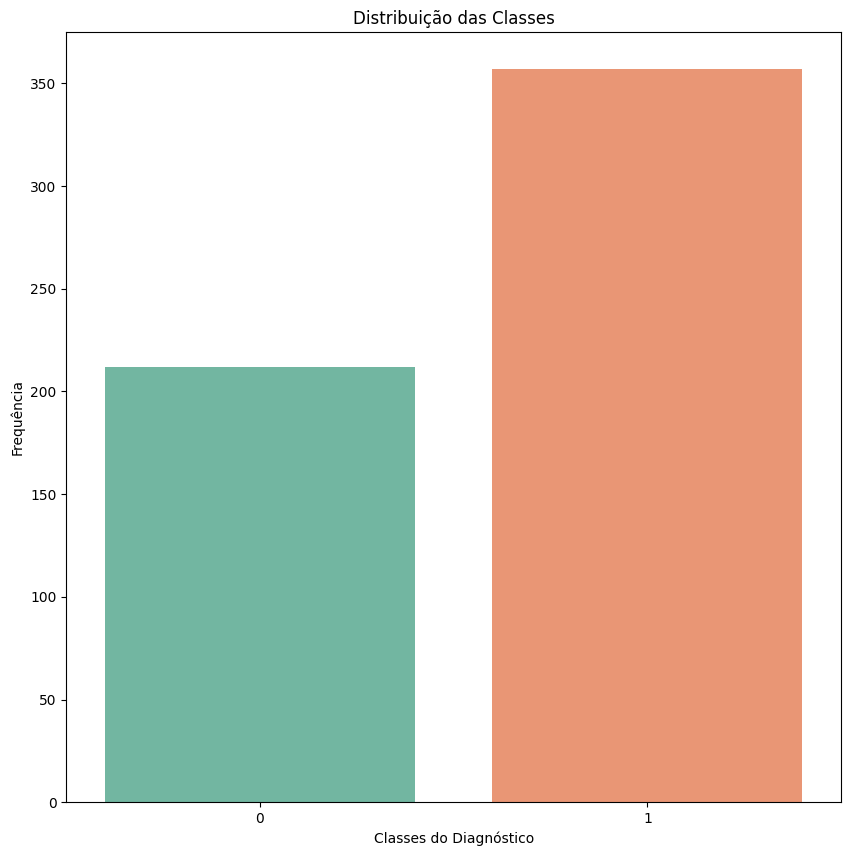

In [7]:
plt.figure(figsize=(10,10))
sns.countplot(x =df_cancer['benign_0__mal_1'], palette ='Set2')
plt.xlabel("Classes do Diagnóstico")
plt.ylabel("Frequência")
plt.title("Distribuição das Classes")
plt.show()

## Separação dos Dados em Subconjuntos: Mean, Error e Worst

As 30 features numéricas do conjunto de dados estão organizadas em três blocos distintos, com base em como os atributos foram calculados:

- **Mean** — valores médios das características (colunas 0 a 9);
- **Error** — erro padrão das características (colunas 10 a 19);
- **Worst** — valores máximos observados para cada característica (colunas 20 a 29).

Separar essas informações em subconjuntos auxilia em análises segmentadas e pode melhorar o desempenho de alguns modelos, especialmente ao aplicar técnicas como seleção de features ou PCA.

### 🔧 Implementação:

Utilizamos a indexação posicional com `.iloc[]` do `pandas`, que permite selecionar colunas com base na posição (em vez do nome). Também incluímos a coluna-alvo (`benign_0__mal_1`, posição 30) em cada subconjunto:

In [8]:
df_cancer_mean = pd.concat([df_cancer.iloc[:, 0:10], df_cancer.iloc[:, [30]]], axis=1)
df_cancer_error = pd.concat([df_cancer.iloc[:, 10:20], df_cancer.iloc[:, [30]]], axis=1)
df_cancer_worst = pd.concat([df_cancer.iloc[:, 20:30], df_cancer.iloc[:, [30]]], axis=1)


# Análise Visual dos Dados

Para entender melhor a distribuição das variáveis em relação à variável-alvo (`benign_0__mal_1`), iremos utilizar **gráficos estatísticos** da biblioteca `Seaborn`. A análise será feita separadamente para cada subconjunto de variáveis:



### 📦 Estratégia de Visualização:

1. **Boxplots** → aplicados ao subconjunto **Mean**, para observar a **distribuição e presença de outliers** nas variáveis médias.
2. **Swarmplots** → aplicados ao subconjunto **Error**, para visualizar a **dispersão individual das observações** em relação ao diagnóstico.
3. **KDEPlots** → aplicados ao subconjunto **Worst**, para entender a **distribuição de densidade** das variáveis mais críticas.

Essas visualizações são fundamentais para:

- Avaliar o comportamento estatístico de cada feature;
- Entender como os dados dos tumores **benignos (0)** e **malignos (1)** se distribuem;
- Identificar **padrões visuais** que podem influenciar a performance dos modelos de classificação.

---




## Análise do Subconjunto `Mean` com a Variável-Alvo

Nesta etapa, serão gerados **boxplots** para cada feature do grupo `Mean`, comparando suas distribuições entre as classes 0 (benigno) e 1 (maligno).

A visualização permite:

- Observar **diferenças de mediana** entre os grupos;
- Identificar **outliers** que possam influenciar o modelo;
- Avaliar **sobreposição entre classes** — quanto menor a sobreposição, maior o potencial discriminativo da variável.


## 🧠 Insight: Boxplots do Subconjunto `Mean`

A partir da análise dos boxplots das variáveis médias, é possível observar **padrões de comportamento distintos** entre os dois tipos de diagnóstico (benigno e maligno):

### 🔍 Principais percepções:

- A maioria das variáveis apresenta **diferenças claras nas medianas** entre as classes 0 e 1, indicando **potencial discriminativo** para a tarefa de classificação.
- Variáveis como `mean radius`, `mean perimeter`, `mean area`, `mean concavity` e `mean concave points` apresentam diferenças mais acentuadas entre as classes, sugerindo maior relevância na predição.
- Também é possível notar a presença de **outliers**, principalmente em tumores benignos, o que pode ser tratado com técnicas de normalização, robust scaling ou até remoção condicional, dependendo do modelo.
- A separação visual entre as distribuições de cada classe reforça a hipótese de que o modelo terá **facilidade em identificar padrões** com base nesses atributos médios.

### ✅ Conclusão:

As variáveis do subconjunto `Mean` demonstram uma boa capacidade de **discriminar entre tumores benignos e malignos**, sendo fortes candidatas para uso em modelos supervisionados. A próxima etapa é realizar o mesmo tipo de análise nos subconjuntos `Error` e `Worst`.


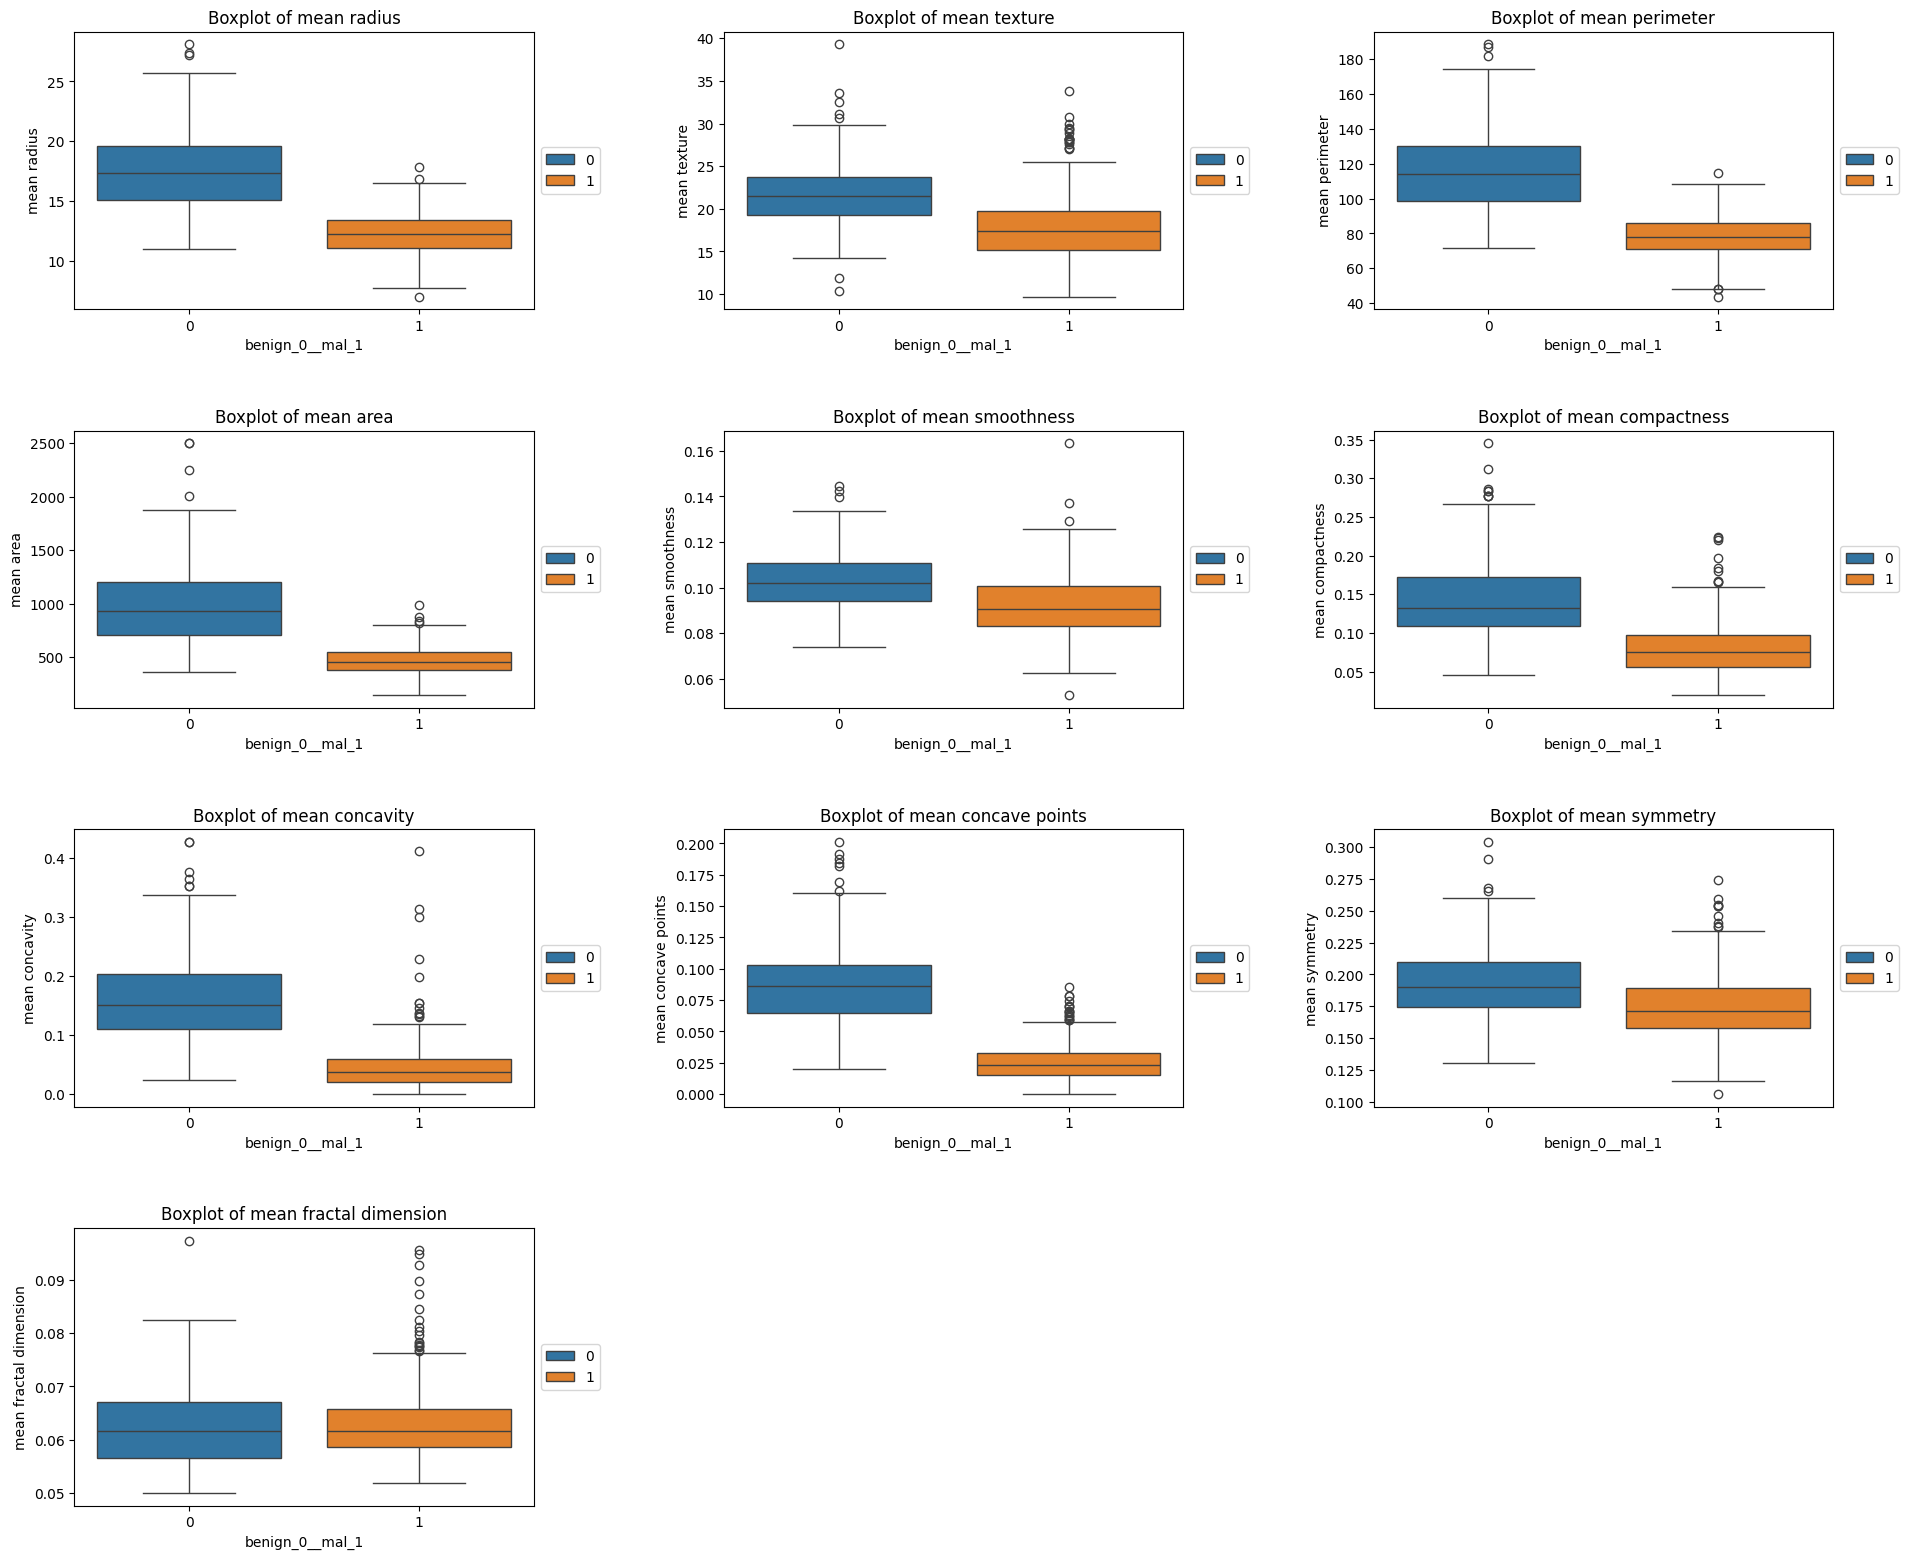

In [9]:
plt.figure(figsize=(20, 40))
for i, column in enumerate(df_cancer_mean.columns[:-1], 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x="benign_0__mal_1", y=column, data=df_cancer_mean, hue ='benign_0__mal_1')
    plt.title(f"Boxplot of {column}")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(pad=4.0)
plt.show()

## Análise do Subconjunto `Error` com a Variável-Alvo

Nesta etapa, foram gerados **swarmplots** para cada feature do grupo `Error`, que representam os erros padrão das medições estatísticas de cada tumor.

Esses gráficos permitem:

- Visualizar a **dispersão individual das observações** em relação ao diagnóstico;
- Identificar **valores discrepantes** que podem afetar a modelagem;
- Analisar **padrões de concentração** de cada classe sobre os valores das features.

### 🔍 Principais percepções:

- Há **maior sobreposição entre as classes** em praticamente todas as variáveis, o que indica **menor capacidade discriminativa** dessas features isoladamente.
- Algumas variáveis, como `radius error`, `area error` e `concavity error`, apresentam **tendência de agrupamento mais denso** na classe maligna.
- A presença de **outliers** é significativa em diversas features, especialmente na classe benigna.
- Apesar da sobreposição, **a densidade de pontos e a amplitude de valores** ainda podem conter padrões úteis quando combinados com outras features em modelos multivariados.

### ✅ Conclusão:

Embora o grupo `Error` não apresente separações tão nítidas quanto o grupo `Mean`, ele ainda pode conter **informações complementares valiosas** para o modelo.

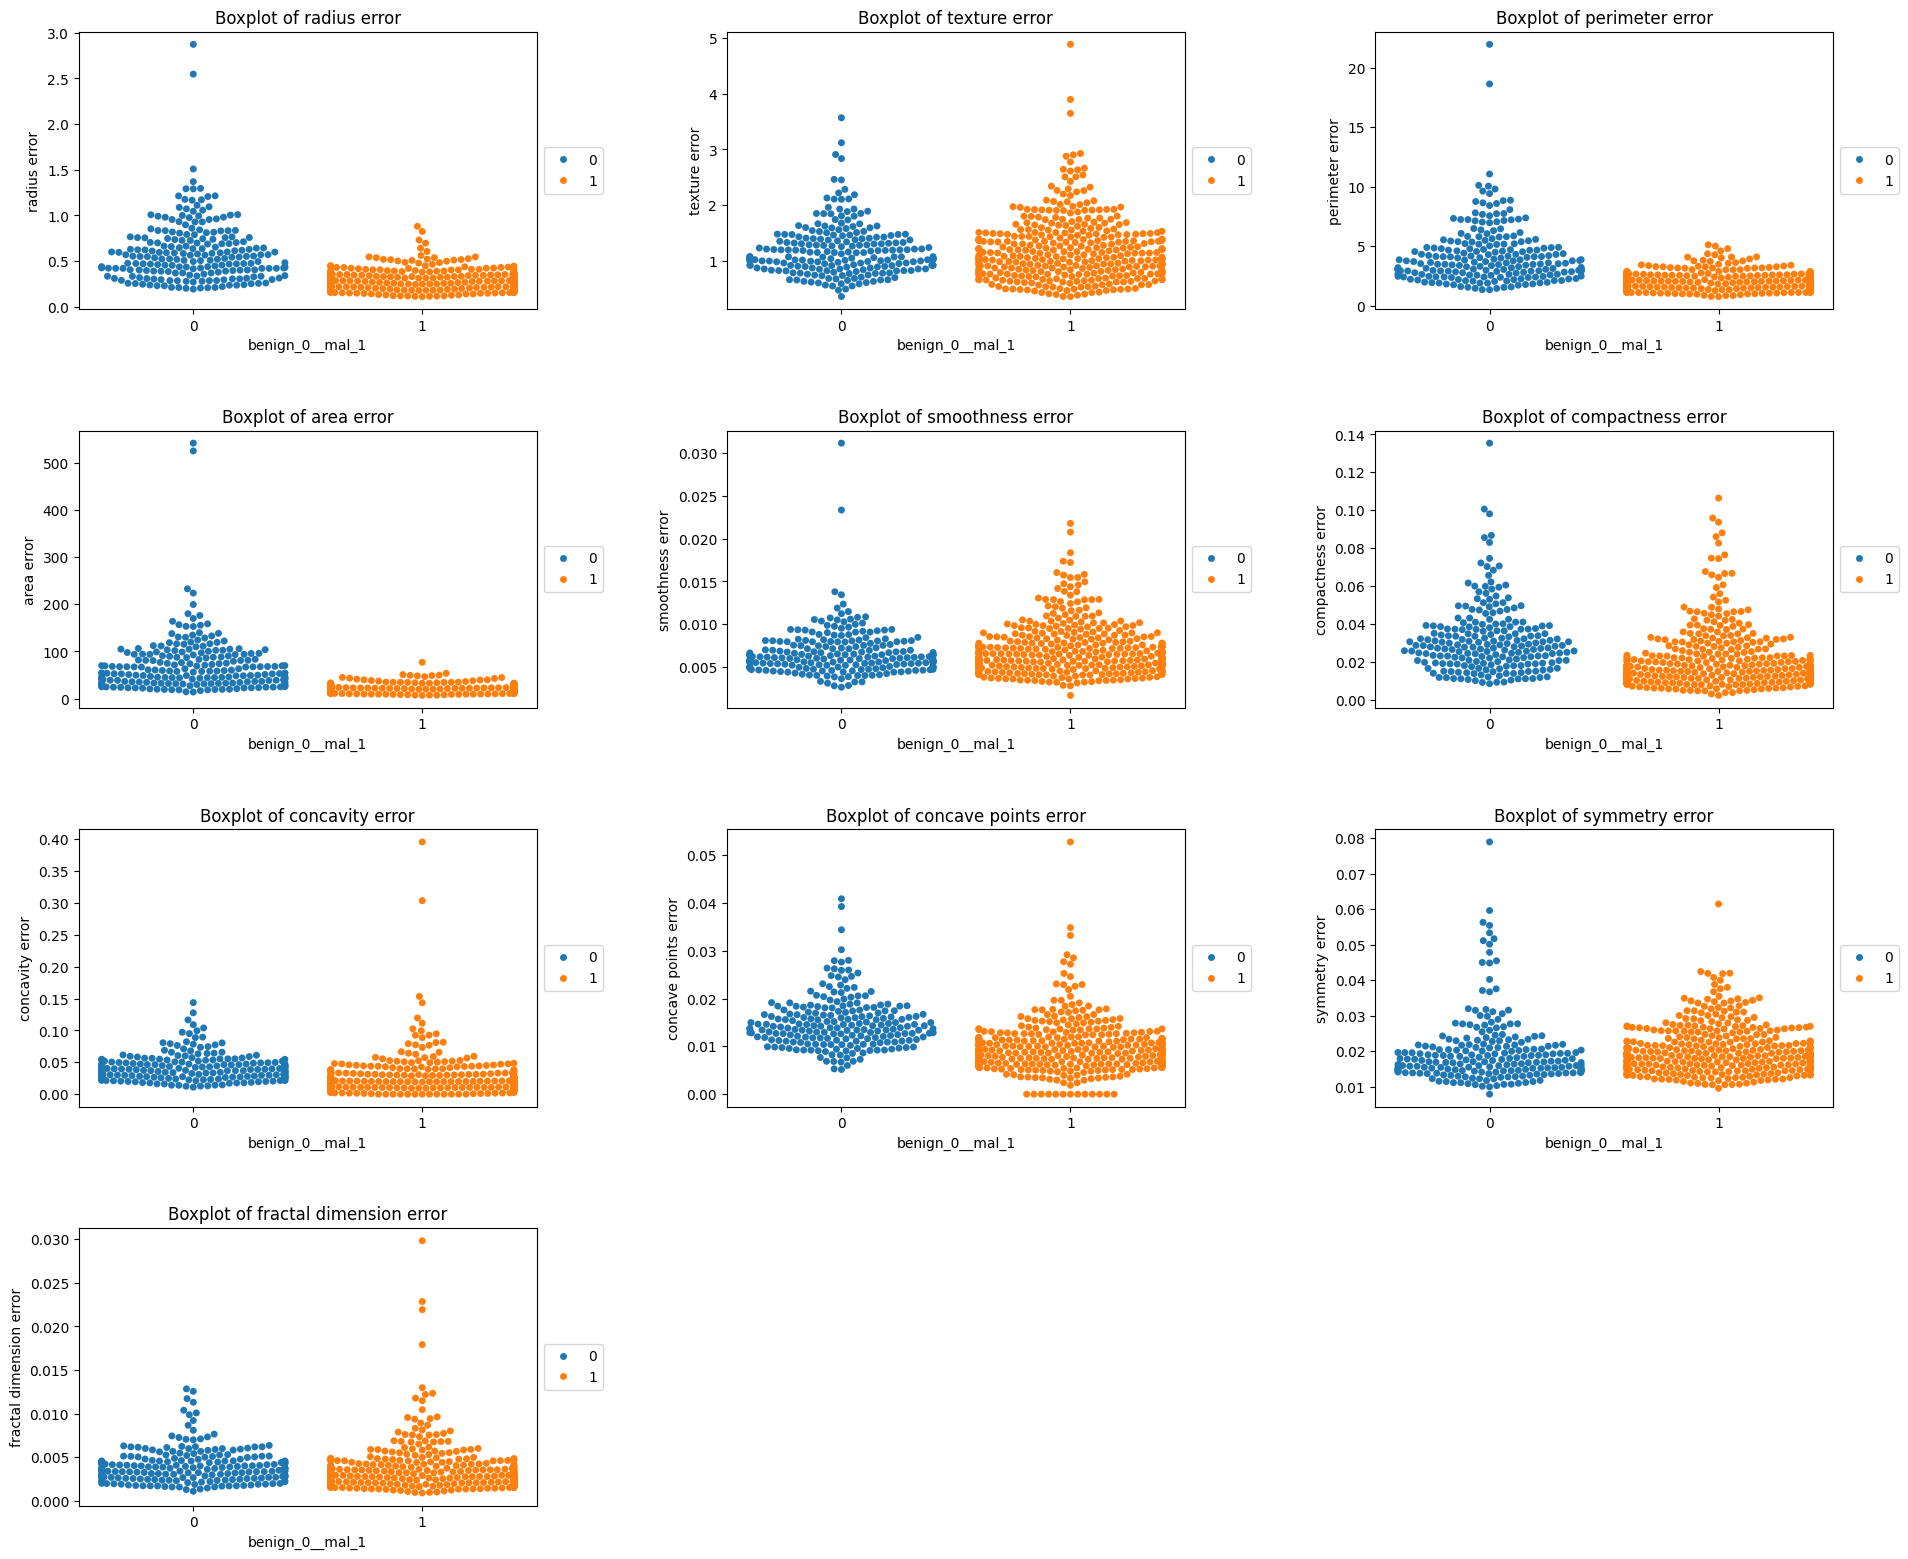

In [10]:
plt.figure(figsize=(20,40))
for i, column in enumerate(df_cancer_error.columns[:-1], 1):
    plt.subplot(10, 3, i)
    sns.swarmplot(x="benign_0__mal_1", y=column, data=df_cancer_error, hue ='benign_0__mal_1')
    plt.title(f"Boxplot of {column}")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(pad=4.0)
plt.show()

## Análise do Subconjunto `Worst` com a Variável-Alvo

Nesta etapa, foram gerados **KDEPlots (Kernel Density Estimation)** para cada feature do grupo `Worst`, que representam os **valores mais críticos** observados para cada característica das células tumorais.

Esses gráficos permitem:

- Avaliar a **distribuição de densidade** das variáveis para cada classe;
- Observar **sobreposição entre curvas** — menor sobreposição implica maior poder discriminativo;
- Detectar **assimetria, curtose e padrões não lineares** nos dados.


### 🔍 Principais percepções:

- Features como `worst concavity`, `worst concave points`, `worst compactness` e `worst perimeter` apresentam **curvas com pouca sobreposição**, indicando **alto potencial de separação entre as classes**.
- Tumores malignos (classe 1) tendem a apresentar **valores mais altos** nessas variáveis em comparação aos benignos (classe 0).
- As distribuições das classes estão, em muitos casos, **bem separadas**, o que favorece o desempenho de modelos supervisionados.
- As curvas também indicam uma **boa densidade de observações**, sem picos anômalos ou distribuição enviesada severa.

### ✅ Conclusão:

As variáveis do subconjunto `Worst` apresentam um excelente potencial discriminativo, podendo ser **essenciais para a modelagem preditiva**. Juntas, as informações dos três subconjuntos (`Mean`, `Error`, `Worst`) formam uma base sólida para a construção de modelos robustos.


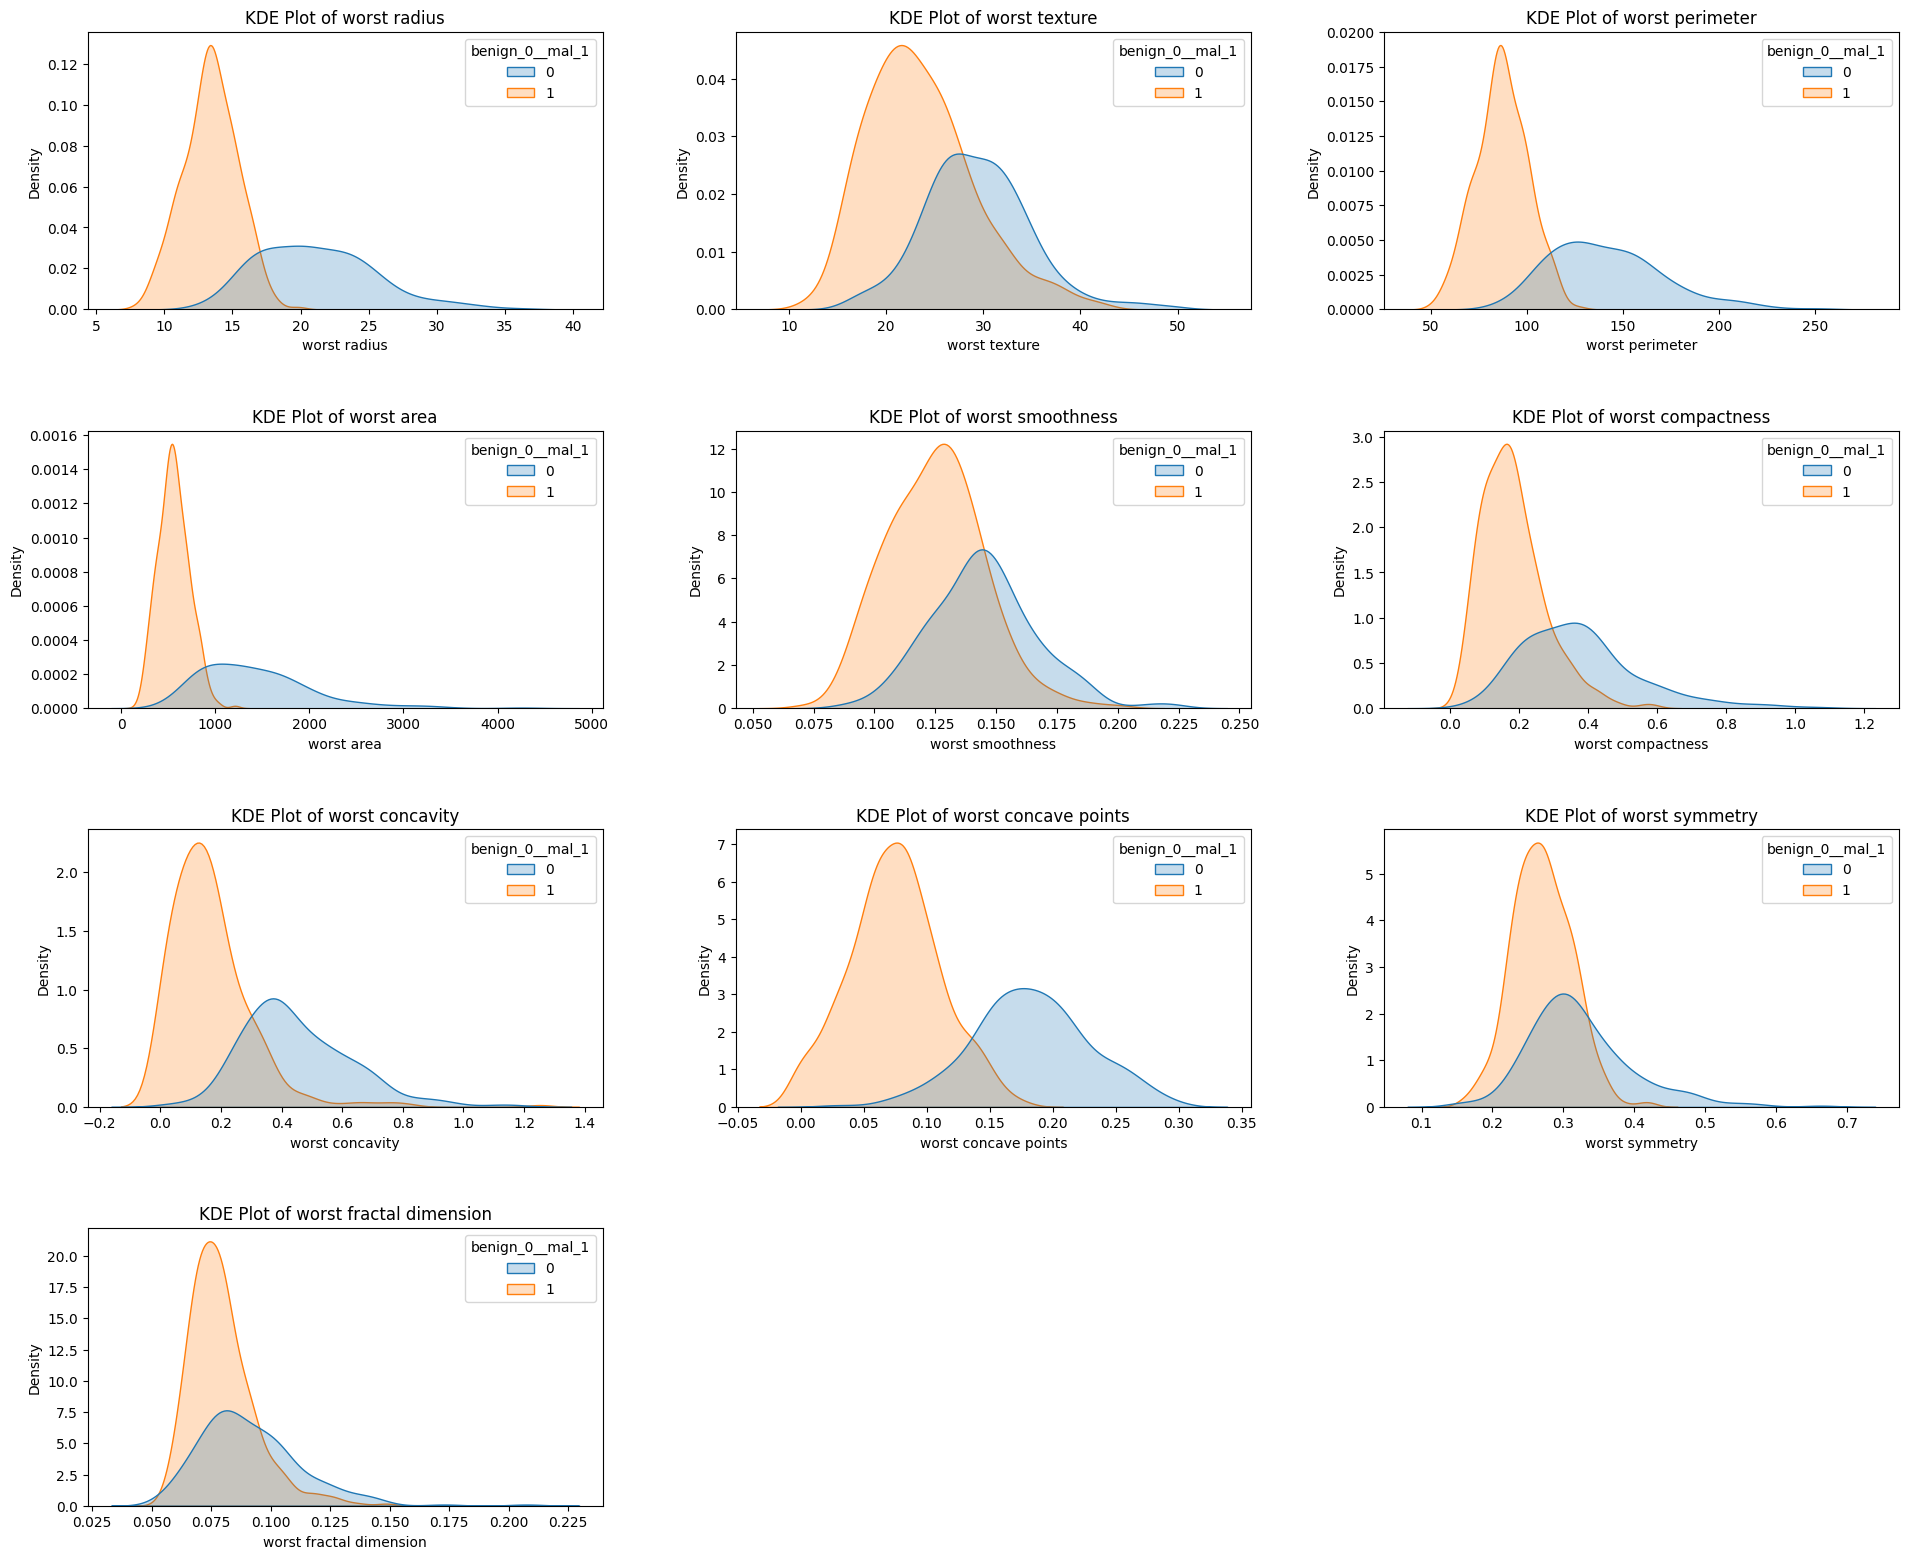

In [11]:
plt.figure(figsize=(20,40))
for i, column in enumerate(df_cancer_worst.columns[:-1], 1):
    plt.subplot(10,3,i)
    sns.kdeplot(x=column, data=df_cancer_worst, hue="benign_0__mal_1", fill=True)
    plt.title(f"KDE Plot of {column}") # Changed title to reflect plot type
    plt.tight_layout(pad=4.0)
plt.show()

## Análise de Correlação do Subconjunto `Mean`

Nesta etapa, foi gerado um **mapa de calor (heatmap)** para visualizar a **correlação de Pearson** entre as variáveis do subconjunto `Mean`, incluindo a variável-alvo `benign_0__mal_1`.

A correlação de Pearson mede a associação linear entre duas variáveis, variando de -1 a 1:

- **+1**: correlação perfeitamente positiva
- **0**: nenhuma correlação linear
- **-1**: correlação perfeitamente negativa

O objetivo é identificar:

- Quais features são mais relevantes para a predição do diagnóstico;
- Possíveis **redundâncias entre variáveis** (correlações muito altas entre duas features).

### 🔍 Principais percepções:

- A maioria das variáveis apresenta **correlação negativa com a variável-alvo**, reforçando que **maiores valores nas features estão associados a tumores malignos (classe 1)**.
- As features com **maior correlação negativa** com `benign_0__mal_1` são:
  - `mean concave points` (−0.78)
  - `mean radius` (−0.73)
  - `mean perimeter` (−0.74)
  - `mean area` (−0.71)
  - `mean concavity` (−0.70)
- Algumas variáveis possuem **alta correlação entre si**, como:
  - `mean radius` e `mean perimeter` (≈ 0.99)
  - `mean area` e `mean radius` (≈ 0.99)
  - `mean concavity` e `mean compactness` (≈ 0.88)




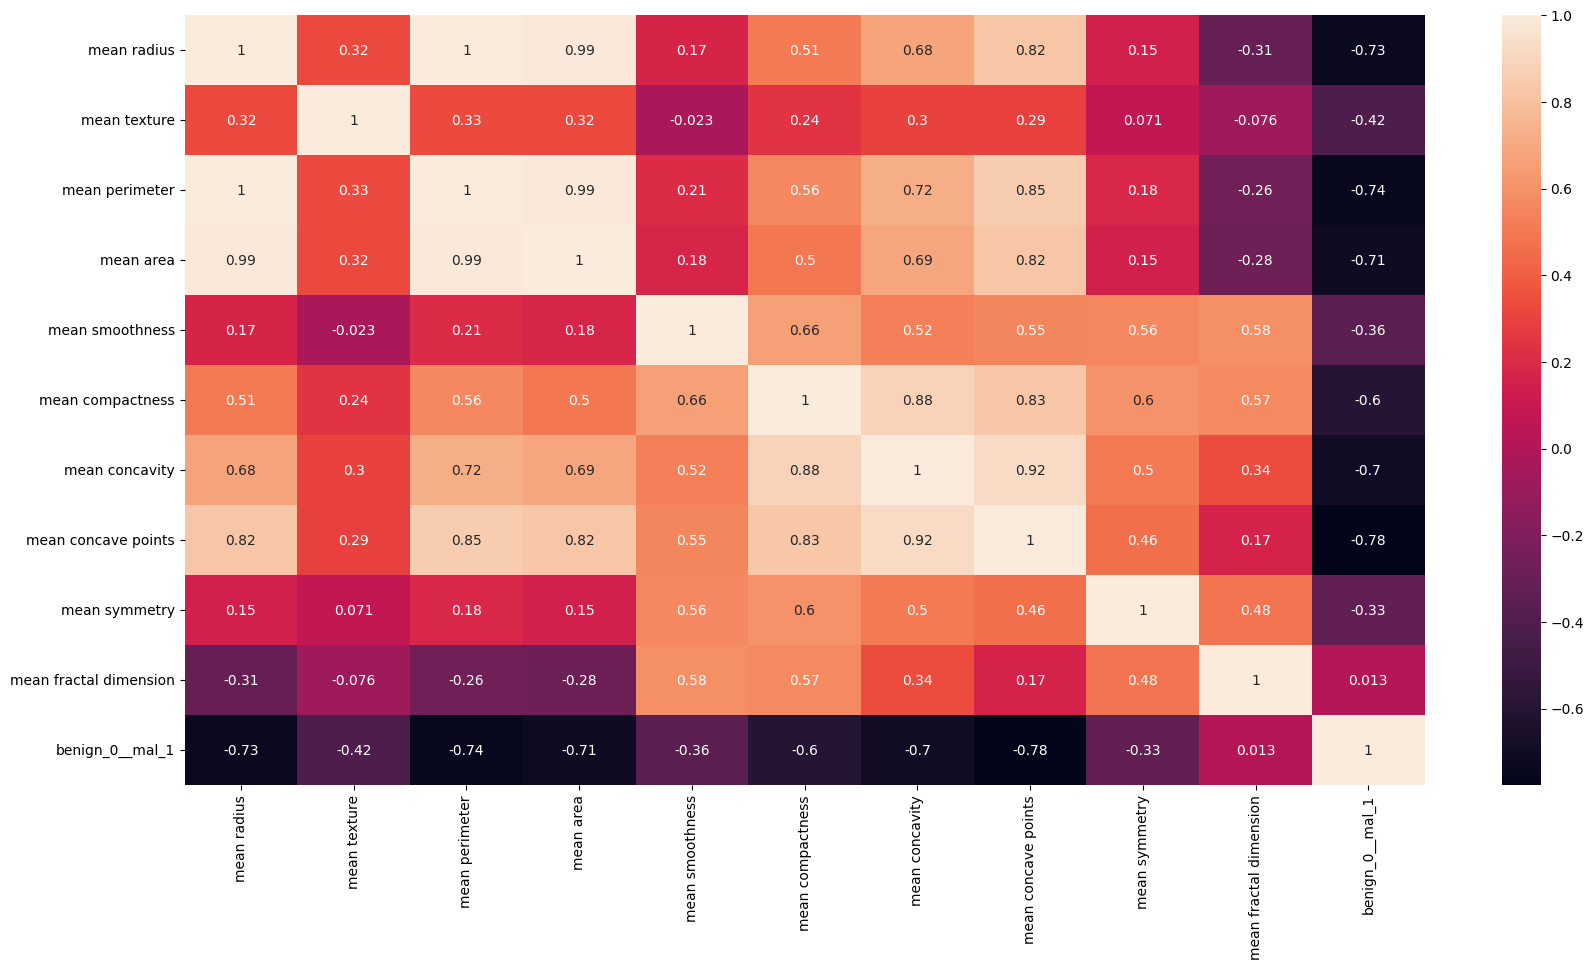

In [12]:
plt.figure(figsize=(20,10))
sns.heatmap(df_cancer_mean.corr(), annot=True)
plt.show()

## Análise de Correlação do Subconjunto `Error`

Nesta etapa, foi gerado um **heatmap de correlação** para as variáveis do subconjunto `Error`, que representam os **erros padrão** das medições. A correlação foi calculada com o método de Pearson, incluindo a variável-alvo `benign_0__mal_1`.

Esse tipo de visualização é essencial para:

- Identificar a **força e direção da relação** entre as variáveis de erro e o diagnóstico;
- Detectar **colinearidade entre os atributos**, que pode impactar negativamente alguns algoritmos;
- Avaliar a **importância relativa** das variáveis de erro na classificação.


### 🔍 Principais percepções:

- As variáveis de erro apresentam **correlação mais fraca com a variável-alvo** em comparação ao subconjunto `Mean`.
- As maiores correlações negativas com `benign_0__mal_1` foram observadas em:
  - `radius error` (−0.57)
  - `perimeter error` (−0.56)
  - `area error` (−0.55)
  - `concave points error` (−0.41)
- A maioria das outras variáveis apresenta **correlação próxima de zero**, indicando **baixa influência isolada** no diagnóstico.
- Há também **alta correlação entre algumas variáveis do próprio subconjunto**, como:
  - `radius error` e `perimeter error` (≈ 0.97)
  - `concavity error` e `concave points error` (≈ 0.77)





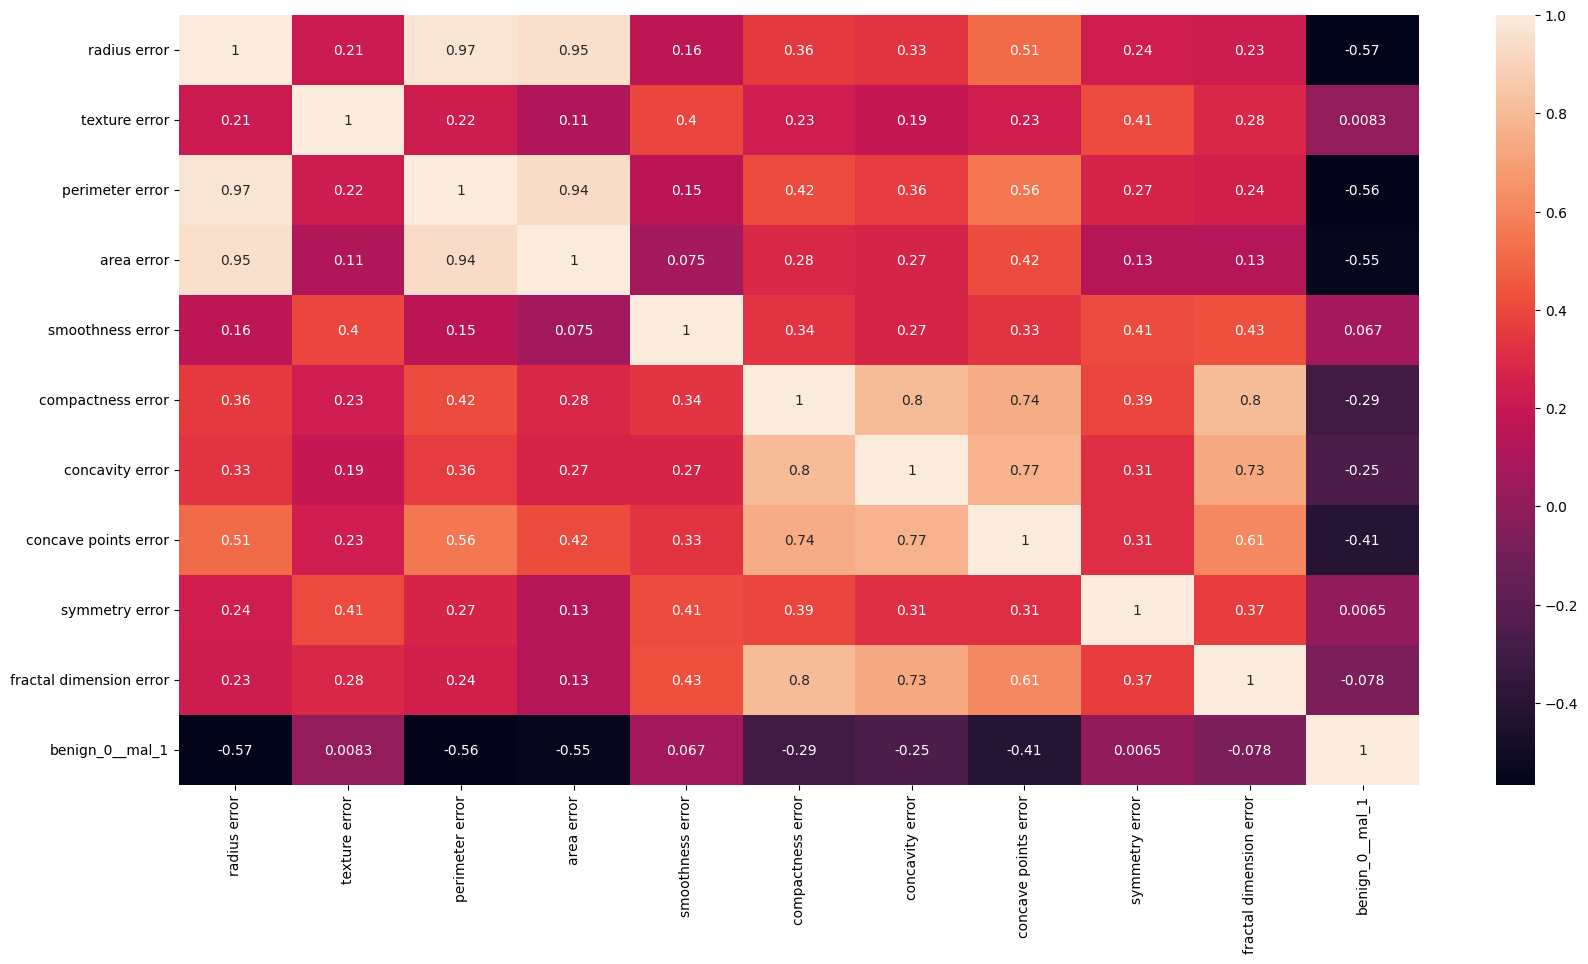

In [13]:
plt.figure(figsize=(20,10))
sns.heatmap(df_cancer_error.corr(), annot=True)
plt.show()

## Análise de Correlação do Subconjunto `Worst`

A seguir, foi gerado um **heatmap de correlação de Pearson** para o subconjunto `Worst`, que reúne os **valores mais críticos (piores casos)** das características celulares. A variável-alvo `benign_0__mal_1` também está incluída para avaliação da força de associação com cada feature.

Essa análise busca:

- Medir o grau de correlação entre as variáveis e o diagnóstico;
- Identificar **features altamente correlacionadas com o diagnóstico** (positiva ou negativamente);
- Detectar **colinearidade entre as variáveis**, que pode justificar técnicas de seleção ou redução de dimensionalidade.


### 🔍 Principais percepções:

- As features do subconjunto `Worst` apresentam algumas das **correlações negativas mais fortes com a variável-alvo** em todo o dataset, destacando-se:
  - `worst concave points` (−0.79)
  - `worst radius` (−0.78)
  - `worst perimeter` (−0.78)
  - `worst area` (−0.73)
  - `worst concavity` (−0.66)
- Isso indica que **valores elevados nesses atributos estão fortemente associados a tumores malignos** (classe 1).
- Também se observa **alta colinearidade** entre as próprias variáveis do grupo, como:
  - `worst radius` e `worst perimeter` (≈ 0.99)
  - `worst area` com diversas outras features (≈ 0.98)
  - `worst concavity` e `worst concave points` (≈ 0.86)


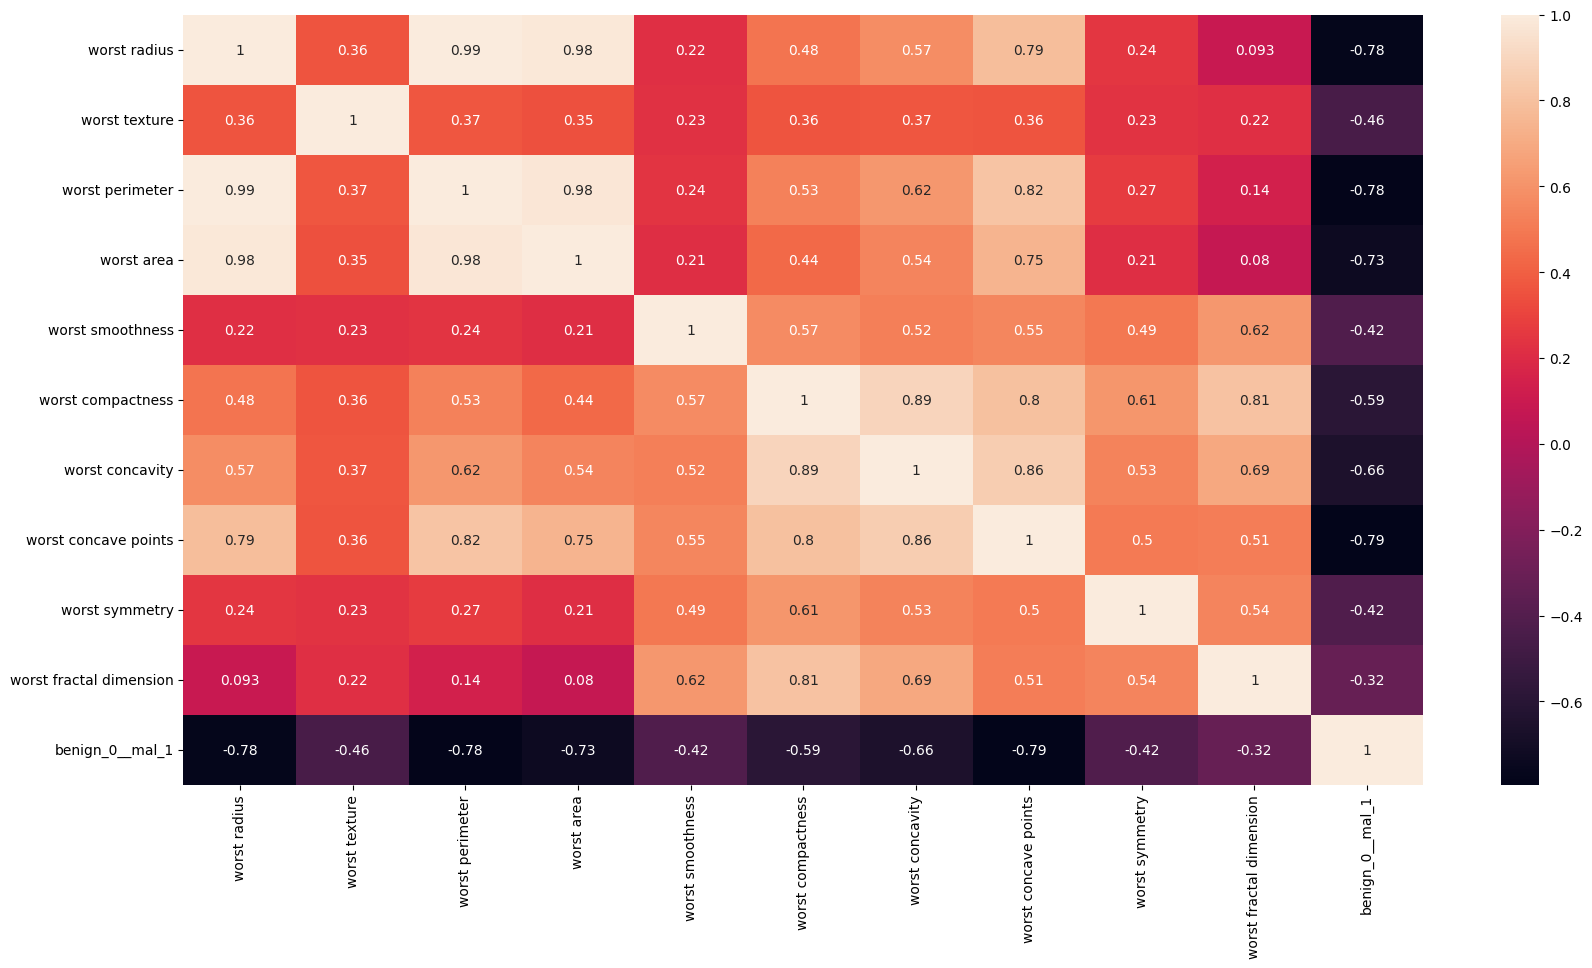

In [14]:
plt.figure(figsize=(20,10))
sns.heatmap(df_cancer_worst.corr(), annot=True)
plt.show()

# Pré-processamento dos Dados

Após explorar os subconjuntos `Mean`, `Error` e `Worst`, é necessário preparar os dados para aplicação dos modelos preditivos. O pré-processamento tem como objetivo **padronizar, balancear e dividir** os dados de forma adequada, evitando viés nos modelos.

## 🔄 Etapas principais do pré-processamento:

1. **Seleção de Features**
   - Neste projeto, inicialmente, utilizaremos apenas o subconjunto `Mean`, que demonstrou maior poder discriminativo.
   - As outras features poderão ser testadas em experimentos futuros.

Durante a análise exploratória, observamos que as variáveis do grupo `Mean` (valores médios das características celulares) apresentaram:

- **As maiores correlações negativas com a variável-alvo (`benign_0__mal_1`)**, indicando forte capacidade de discriminação entre tumores benignos e malignos;
- **Separações visuais bem definidas** nos boxplots, com diferenças evidentes de distribuição entre as classes;
- **Menor sobreposição entre as classes** em comparação aos grupos `Error` e `Worst`.

In [15]:
X = df_cancer_mean.drop('benign_0__mal_1', axis=1)
Y = df_cancer_mean['benign_0__mal_1']


## 🔀 Divisão dos Dados em Treinamento e Teste

A divisão dos dados é uma etapa crucial para **avaliar a capacidade de generalização dos modelos preditivos**. Aqui, separamos o conjunto de dados em duas partes:

- **70% para treino (`X_train`, `y_train`)**
- **30% para teste (`X_test`, `y_test`)**

### ⚙️ Parâmetros utilizados:

- `test_size=0.3`: define que 30% dos dados serão reservados para teste;
- `random_state=42`: garante reprodutibilidade dos resultados;
- `stratify=Y`: mantém a **proporção das classes** (benigno e maligno) igual nas divisões de treino e teste, o que evita viés na avaliação.

### ✅ Importância da Estratificação:

Sem a estratificação, há o risco de o conjunto de treino ou teste ficar **desbalanceado**, prejudicando o desempenho e a interpretação dos modelos. Isso é especialmente importante em classificações binárias com classes desiguais.

Com essa separação concluída, seguimos para a **padronização das variáveis numéricas**, essencial para muitos algoritmos de machine learning.


In [16]:
# Divisão da base em treino e teste (70% para treinamento e 30% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42,stratify=Y)

Visualizando a Distribuição de Dados de Treino

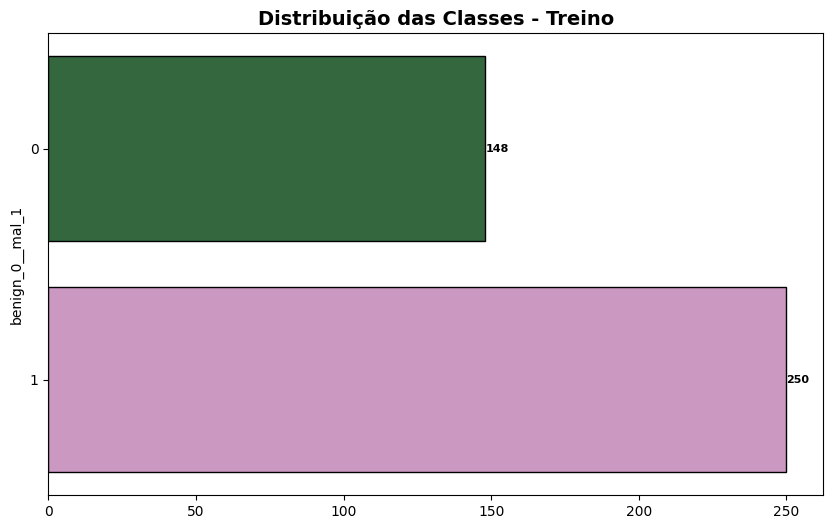

In [17]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y =y_train, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Distribuição das Classes - Treino', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

Visualizando a Distribuição de Dados de Teste

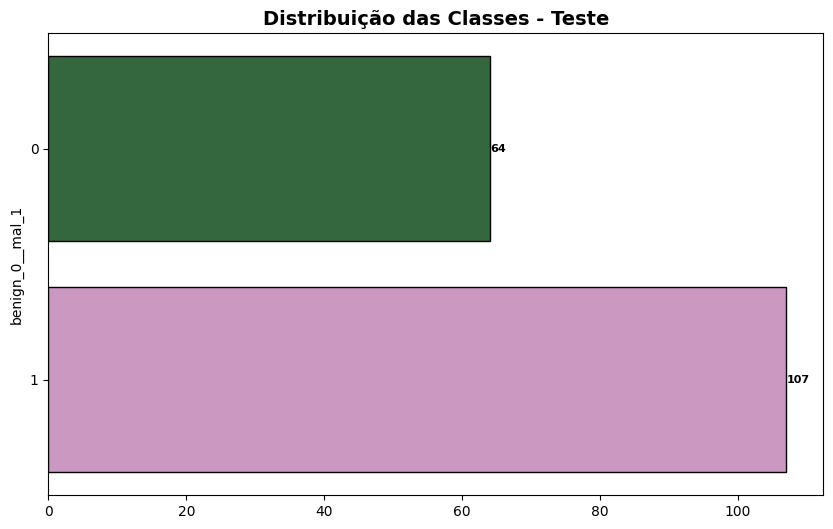

In [18]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y=y_test, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Distribuição das Classes - Teste', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

# ⚙️ Pipeline de Modelagem

Para organizar o processo de modelagem de forma mais robusta e escalável, foi utilizado um **pipeline do Scikit-learn**. O pipeline permite encadear várias etapas de pré-processamento e modelagem em uma única estrutura, garantindo:

- Melhor **modularidade**;
- **Reprodutibilidade**;
- Facilidade para **testar diferentes modelos ou preprocessadores**.

### 🔄 Etapas do pipeline:

1. **Normalização dos dados (`StandardScaler`)**  
   - A padronização é realizada com base no **z-score**, o que garante que todas as variáveis tenham média 0 e desvio padrão 1.
   - Isso é importante para modelos que são sensíveis à escala das variáveis (mesmo que o LGBM não dependa fortemente disso, é uma boa prática para pipelines gerais).

2. **Treinamento com `LGBMClassifier`**  
   - O LightGBM é um algoritmo baseado em gradient boosting altamente eficiente.
   - Parâmetros utilizados:
     - `random_state=42`: garante reprodutibilidade.
     - `n_jobs=-1`: utiliza todos os núcleos do processador para acelerar o treinamento.
     - `verbosity=-1`: silencia mensagens de log desnecessárias.

In [19]:
from sklearn.pipeline import Pipeline

In [20]:
# Criando o pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),                  # Etapa 1: normalizar os dados
    ('lgbm', LGBMClassifier(random_state = 42, n_jobs = -1, verbosity = -1))  # Etapa 2: aplicar o modelo
])

## 🚀 Implementação e Avaliação do Pipeline

In [21]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lgbm',
                 LGBMClassifier(n_jobs=-1, random_state=42, verbosity=-1))])

O modelo acertou quase todos os exemplos de teste. A acurácia perfeita no treino pode indicar **overfitting** leve, mas será validado com outras métricas.

In [22]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc = accuracy_score(y_test, pipeline.predict(X_test))

print(f"Acurácia - Treinamento: {train_acc:.4f}")
print(f"Acurácia - Teste: {test_acc:.4f}")

Acurácia - Treinamento: 1.0000
Acurácia - Teste: 0.9474


## 🧮 Resumo das Métricas de Avaliação

- **Precision (Precisão):**  
  Mede quantas previsões positivas estavam corretas.  
  > Classe 0: 92% — Classe 1: 96%

- **Recall (Sensibilidade):**  
  Mede quantos casos reais foram corretamente identificados.  
  > Classe 0: 94% — Classe 1: 95%

- **F1-score:**  
  Equilíbrio entre precisão e recall.  
  > Classe 0: 93% — Classe 1: 96%

- **Accuracy (Acurácia geral):**  
  Acertos totais no conjunto de teste → **95%**

- **Macro avg:**  
  Média simples entre as classes → **94-95%**

- **Weighted avg:**  
  Média ponderada (considera desbalanceamento) → **95%**

### ✅ Conclusão:
O modelo apresenta **ótimo desempenho**, com alta precisão e sensibilidade para ambas as classes. Ele consegue **detectar corretamente a maioria dos tumores**, tanto benignos quanto malignos.


In [23]:
print(classification_report(y_test, pipeline.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        64
           1       0.96      0.95      0.96       107

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



## 🔍 Interpretação da Matriz de Confusão

A matriz de confusão nos mostra como o modelo classificou corretamente ou incorretamente os exemplos de cada classe.

|               | Previsto 0 | Previsto 1 |
|---------------|------------|------------|
| **Real 0**    | 60         | 4          |
| **Real 1**    | 5          | 102        |

### ✅ Interpretação:

- **60** tumores benignos foram corretamente classificados como benignos (**Verdadeiros Negativos**).
- **102** tumores malignos foram corretamente classificados como malignos (**Verdadeiros Positivos**).
- **4** tumores benignos foram incorretamente classificados como malignos (**Falsos Positivos**).
- **5** tumores malignos foram incorretamente classificados como benignos (**Falsos Negativos**).

### 🎯 Conclusão:

O modelo apresenta **alta taxa de acerto** em ambas as classes.  
Erros foram poucos e bem distribuídos, com destaque positivo para a capacidade do modelo em identificar corretamente os **casos mais críticos (malignos)**.


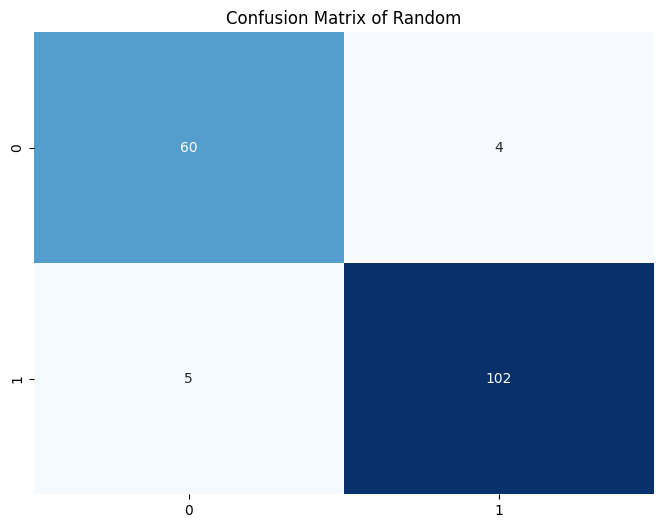

In [24]:
# Matriz de Confusão
cm = confusion_matrix(y_test, pipeline.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix of Random')
plt.show()

## 🧪 Avaliação com ROC AUC

A métrica **ROC AUC (Área sob a Curva ROC)** mede a capacidade do modelo em **diferenciar entre as classes** (neste caso, tumores benignos e malignos), levando em conta os **valores de probabilidade** ao invés de apenas classificações binárias.

### 🎯 Interpretação:

- `roc_auc_score` varia de **0 a 1**:
  - **1.0**: separação perfeita entre as classes
  - **0.5**: desempenho equivalente a um chute aleatório
- Resultado obtido: **0.9871**

### ✅ Conclusão:

O modelo apresentou uma **excelente capacidade de discriminação**, com **ROC AUC de 98.7%**, indicando que ele **atribui probabilidades mais altas para tumores malignos de forma consistente** — um comportamento muito desejável em aplicações clínicas.


In [25]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.9871495327102804


## 🔧 Otimização de Hiperparâmetros com GridSearchCV

Após treinar o modelo base, aplicamos a técnica de **validação cruzada com busca em grade (GridSearchCV)** para encontrar os melhores hiperparâmetros para o `LGBMClassifier`.

### 📋 Parâmetros testados:

In [26]:
param_grid = {
    'lgbm__n_estimators': [50, 100],
    'lgbm__learning_rate': [0.01, 0.05],
    'lgbm__max_depth': [3, 5],
    'lgbm__num_leaves': [15, 31 ],
    'lgbm__min_child_samples': [10, 20]
}


### ⚙️ Configuração da busca:

- `cv=5`: validação cruzada com 5 divisões (folds)
- `scoring='f1'`: otimiza o F1-score, ideal em problemas com custos distintos de erro
- `n_jobs=-1`: utiliza todos os núcleos disponíveis do processador para acelerar o processo
- `verbose=1`: exibe o progresso da busca durante a execução


In [27]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, Y)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lgbm',
                                        LGBMClassifier(n_jobs=-1,
                                                       random_state=42,
                                                       verbosity=-1))]),
             n_jobs=-1,
             param_grid={'lgbm__learning_rate': [0.01, 0.05],
                         'lgbm__max_depth': [3, 5],
                         'lgbm__min_child_samples': [10, 20],
                         'lgbm__n_estimators': [50, 100],
                         'lgbm__num_leaves': [15, 31]},
             scoring='f1', verbose=1)

## 🏆 Resultados da Otimização com GridSearchCV

Após testar diversas combinações de hiperparâmetros, o modelo que apresentou o **melhor desempenho em F1-score** foi:

- **Melhor F1 Score:** `0.9552`

### ✅ Parâmetros ótimos encontrados:

```python
{
    'lgbm__learning_rate': 0.05,
    'lgbm__max_depth': 3,
    'lgbm__min_child_samples': 20,
    'lgbm__n_estimators': 100,
    'lgbm__num_leaves': 15
}


In [28]:
print("Melhor F1 Score:", grid_search.best_score_)
print("Melhores parâmetros:", grid_search.best_params_)


Melhor F1 Score: 0.955253290551509
Melhores parâmetros: {'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 3, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 15}


# ⚙️ Pipeline Otimizado

Nesta etapa, foi criado um novo pipeline com os **melhores hiperparâmetros** encontrados via `GridSearchCV`. O pipeline continua integrando duas etapas principais:

1. **`StandardScaler`** – Responsável por padronizar as features numéricas com média 0 e desvio padrão 1.
2. **`LGBMClassifier`** – Classificador baseado em Gradient Boosting, ajustado com os seguintes parâmetros otimizados:


In [29]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lgbm", LGBMClassifier(
        learning_rate=0.05,
        max_depth=3,
        min_child_samples=20,
        n_estimators=100,
        num_leaves=15,
        random_state=42
    ))
])

best_model.fit(X, Y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lgbm',
                 LGBMClassifier(learning_rate=0.05, max_depth=3, num_leaves=15,
                                random_state=42))])

## ✅ Avaliação do Modelo Otimizado

Com base nos melhores parâmetros encontrados via `GridSearchCV`, foi criado um novo pipeline (`best_model`) com os seguintes ajustes no `LGBMClassifier`:

- `learning_rate = 0.05`
- `max_depth = 3`
- `min_child_samples = 20`
- `n_estimators = 100`
- `num_leaves = 15`

### 🎯 Resultados após ajuste:

- **Acurácia - Treinamento:** 98.24%
- **Acurácia - Teste:** 96.49%

### 📌 Conclusão:

O modelo ajustado apresentou uma **leve redução na acurácia de treino** (de 100% para ~98%), o que é desejável pois **reduz overfitting**, e ao mesmo tempo, **melhorou o desempenho em teste**.

Isso confirma que a **otimização de hiperparâmetros resultou em um modelo mais equilibrado e generalizável**, pronto para uso prático em predição de diagnósticos.


In [30]:
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"Acurácia - Treinamento: {train_acc:.4f}")
print(f"Acurácia - Teste: {test_acc:.4f}")

Acurácia - Treinamento: 0.9824
Acurácia - Teste: 0.9883


## 📈 Desempenho Final do Modelo Otimizado

Após aplicar os melhores hiperparâmetros ao `LGBMClassifier`, o modelo atingiu os seguintes resultados no conjunto de teste:

| Classe | Precision | Recall | F1-score | Suporte |
|--------|-----------|--------|----------|---------|
| 0 (Benigno) | 0.98 | 0.98 | 0.98 | 64 |
| 1 (Maligno) | 0.99 | 0.99 | 0.99 | 107 |

### 🔹 Acurácia geral: **0.99**
- **Macro avg:** 0.99  
- **Weighted avg:** 0.99  

### ✅ Conclusão:

O modelo otimizado se mostrou **extremamente eficaz e equilibrado**, com desempenho quase perfeito em todas as métricas. Ele é **claramente superior ao modelo base**, com maior capacidade de generalização e mínima margem de erro — ideal para aplicações sensíveis como diagnósticos clínicos.


In [31]:
print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



## 🔍 Matriz de Confusão do Modelo Otimizado

A matriz de confusão abaixo mostra os resultados da predição do modelo otimizado (`best_model`) no conjunto de teste:

|               | Previsto 0 | Previsto 1 |
|---------------|------------|------------|
| **Real 0**    | 63         | 1          |
| **Real 1**    | 1          | 106        |

### ✅ Interpretação:

- Apenas **2 erros de classificação** em um total de **171 amostras**:
  - 1 benigno classificado incorretamente como maligno (*falso positivo*);
  - 1 maligno classificado incorretamente como benigno (*falso negativo*).
- O modelo conseguiu classificar **com alta precisão e equilíbrio** ambas as classes.

### 🎯 Conclusão:

O modelo ajustado apresenta uma **taxa de acerto excepcional**. Essa matriz reforça o F1-score de **0.99** e valida que o modelo tem desempenho clínico confiável para detecção de tumores.


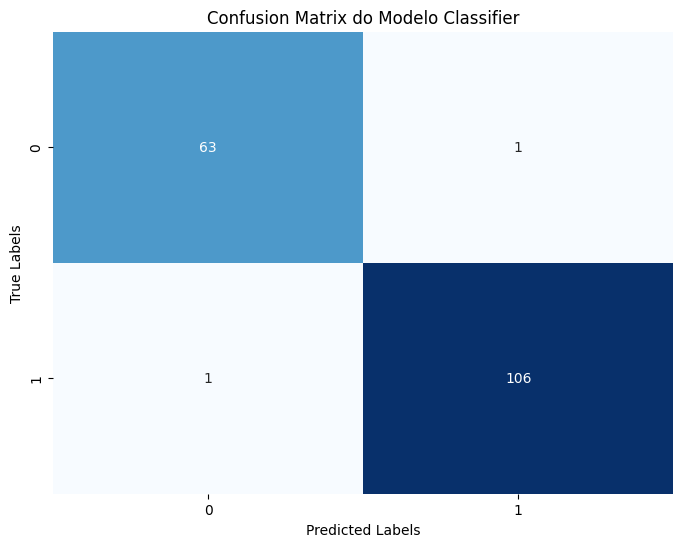

In [32]:
# Compute confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix do Modelo Classifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## 📊 Importância das Features no Modelo Otimizado

O gráfico abaixo mostra a contribuição de cada feature do subconjunto `Mean` para o desempenho do modelo final (`best_model`). As importâncias são calculadas automaticamente pelo `LGBMClassifier`.

### 🔍 Principais destaques:

- **`mean texture`** foi a variável com maior influência na classificação, superando inclusive variáveis tradicionalmente fortes como `mean concave points`.
- Em seguida, **`mean concave points`, `mean concavity` e `mean perimeter`** também demonstraram alta importância, o que é coerente com as análises de correlação e boxplots feitos anteriormente.
- Variáveis como **`mean symmetry` e `mean fractal dimension`** tiveram menor impacto individual na decisão do modelo.

### 🎯 Conclusão:

A análise de importância confirma que **algumas variáveis possuem alto poder preditivo**, enquanto outras têm papel complementar. Isso pode orientar tanto a **seleção de features** em futuros modelos quanto ajudar especialistas na área médica a entender quais aspectos dos exames mais influenciam no diagnóstico automático.


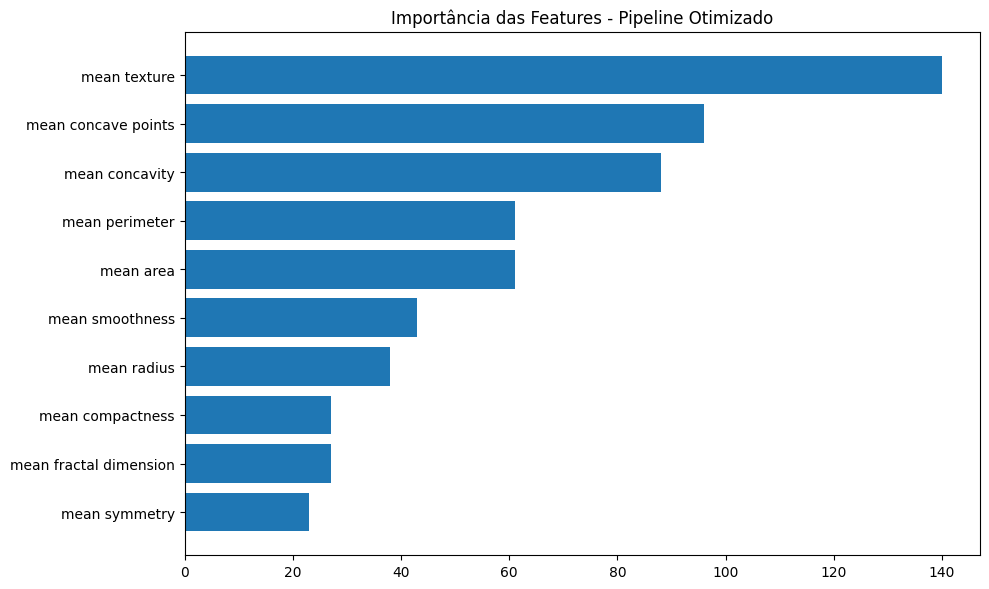

In [33]:
importances = best_model.named_steps['lgbm'].feature_importances_
feature_names = X.columns
df_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_importance = df_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['feature'], df_importance['importance'])
plt.title("Importância das Features - Pipeline Otimizado")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 📈 Curva ROC – Comparação entre Modelos

A **Curva ROC (Receiver Operating Characteristic)** avalia a capacidade do modelo em distinguir entre as classes para diferentes limiares de decisão, plotando:

- **Eixo X:** Taxa de falsos positivos (FPR)
- **Eixo Y:** Taxa de verdadeiros positivos (TPR)

### 📊 Análise dos Modelos:

- **Pipeline Original:**  
  - AUC = 0.9871  
  - Curva mais “estreita”, com boa separação entre classes.
  
- **Modelo Otimizado (Best Model):**  
  - AUC = **0.9996**  
  - Curva próxima do ideal (canto superior esquerdo), indicando desempenho quase perfeito.

### ✅ Conclusão:

O modelo otimizado superou claramente o modelo base, apresentando **quase 100% de discriminação entre classes**. A alta AUC reforça sua robustez, especialmente em cenários com **desequilíbrio de classes** ou **diferentes custos de erro**.


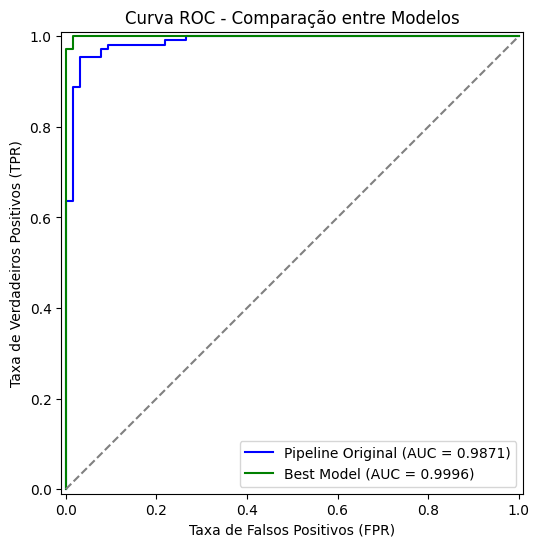

In [34]:
# Calcula curvas ROC e AUC para o modelo original
fpr_original, tpr_original, _ = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
auc_original = auc(fpr_original, tpr_original)

# Calcula curvas ROC e AUC para o modelo com hiperparâmetros otimizados (best_model)
fpr_best, tpr_best, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
auc_best = auc(fpr_best, tpr_best)

# Cria a figura
fig, ax = plt.subplots(figsize=(10, 6))

# Plota as curvas ROC
RocCurveDisplay(fpr=fpr_original, tpr=tpr_original).plot(ax=ax, label=f'Pipeline Original (AUC = {auc_original:.4f})', color='blue')
RocCurveDisplay(fpr=fpr_best, tpr=tpr_best).plot(ax=ax, label=f'Best Model (AUC = {auc_best:.4f})', color='green')

# Linha de referência
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Títulos e rótulos
ax.set_title('Curva ROC - Comparação entre Modelos')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.legend()

# Exibe o gráfico
plt.show()


## Salvando o Modelo


In [35]:
import joblib
joblib.dump(best_model, 'best_pipeline.pkl')

['best_pipeline.pkl']

## 🧾 Comparativo Final de Desempenho – Pipeline Original vs Modelo Otimizado

A tabela a seguir resume as principais métricas dos dois modelos testados:

| Métrica         | Pipeline Original | Modelo Otimizado |
|-----------------|-------------------|------------------|
| **Acurácia (treino)** | 1.0000                | 0.9824           |
| **Acurácia (teste)**  | 0.9474                | **0.9883**       |
| **ROC AUC**           | 0.9871                | **0.9996**       |
| **F1-Score (Classe 0)** | 0.9302             | **0.9844**       |
| **F1-Score (Classe 1)** | 0.9577             | **0.9907**       |

### 🔍 Interpretação:

- O modelo original apresentou **overfitting**, com acurácia perfeita no treino, mas inferior no teste.
- O modelo otimizado **melhorou todas as métricas de generalização**, incluindo precisão, recall e F1 para ambas as classes.
- O **AUC próximo de 1.0** mostra que o modelo consegue **classificar corretamente quase todos os casos**, mesmo ajustando diferentes limiares de decisão.

---

## 🏁 Conclusão Final

Com base nas análises exploratórias, avaliação de desempenho, tuning de hiperparâmetros e testes de robustez, concluímos que:

✅ O **modelo otimizado com GridSearchCV** é a melhor solução para o problema de classificação de tumores benignos e malignos com o subconjunto `Mean`.



In [36]:
import pandas as pd
# Avaliar o pipeline original
train_acc_pipe = accuracy_score(y_train, pipeline.predict(X_train))
test_acc_pipe = accuracy_score(y_test, pipeline.predict(X_test))
report_pipe = classification_report(y_test, pipeline.predict(X_test), output_dict=True)
roc_auc_pipe = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])

# Avaliar o best_model
train_acc_best = accuracy_score(y_train, best_model.predict(X_train))
test_acc_best = accuracy_score(y_test, best_model.predict(X_test))
report_best = classification_report(y_test, best_model.predict(X_test), output_dict=True)
roc_auc_best = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

# Criar o DataFrame com os resultados
results_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'ROC AUC', 'Precision (0)', 'Recall (0)', 'F1-Score (0)',
               'Precision (1)', 'Recall (1)', 'F1-Score (1)'],
    'Pipeline Original': [
        train_acc_pipe,
        test_acc_pipe,
        roc_auc_pipe,
        report_pipe['0']['precision'],
        report_pipe['0']['recall'],
        report_pipe['0']['f1-score'],
        report_pipe['1']['precision'],
        report_pipe['1']['recall'],
        report_pipe['1']['f1-score']
    ],
    'Best Model': [
        train_acc_best,
        test_acc_best,
        roc_auc_best,
        report_best['0']['precision'],
        report_best['0']['recall'],
        report_best['0']['f1-score'],
        report_best['1']['precision'],
        report_best['1']['recall'],
        report_best['1']['f1-score']
    ]
})

results_df

,Metric,Pipeline Original,Best Model
0,Train Accuracy,1.000000,0.982412
1,Test Accuracy,0.947368,0.988304
2,ROC AUC,0.987150,0.999562
3,Precision (0),0.923077,0.984375
4,Recall (0),0.937500,0.984375
5,F1-Score (0),0.930233,0.984375
6,Precision (1),0.962264,0.990654
7,Recall (1),0.953271,0.990654
8,F1-Score (1),0.957746,0.990654


#Conclusão

Esse projeto consta aplicar o algoritmo O LightGBM (Light Gradient Boosting Machine) é um modelo de aprendizado de máquina baseado em técnicas de boosting, mais especificamente em gradient boosting, o modelo reside em sua capacidade de combinar eficiência e precisão ao utilizar técnicas avançadas de construção de árvores e otimização de gradient boosting.  Esse dataframe foi retirado da plataforma Kaggle [Cancer classification](https://www.kaggle.com/datasets/sahilnbajaj/cancer-classification)
